In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))

io$plot.dir = file.path(io$output.directory,'Plots')
dir.create(file.path(io$plot.dir), showWarnings = FALSE)
io$plot.genes = file.path(io$plot.dir,'Genes')
dir.create(file.path(io$plot.genes), showWarnings = FALSE)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
       

In [2]:
addArchRThreads(threads = 12) 

Setting default number of Parallel threads to 12.



Length of unique values greater than palette, interpolating..

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



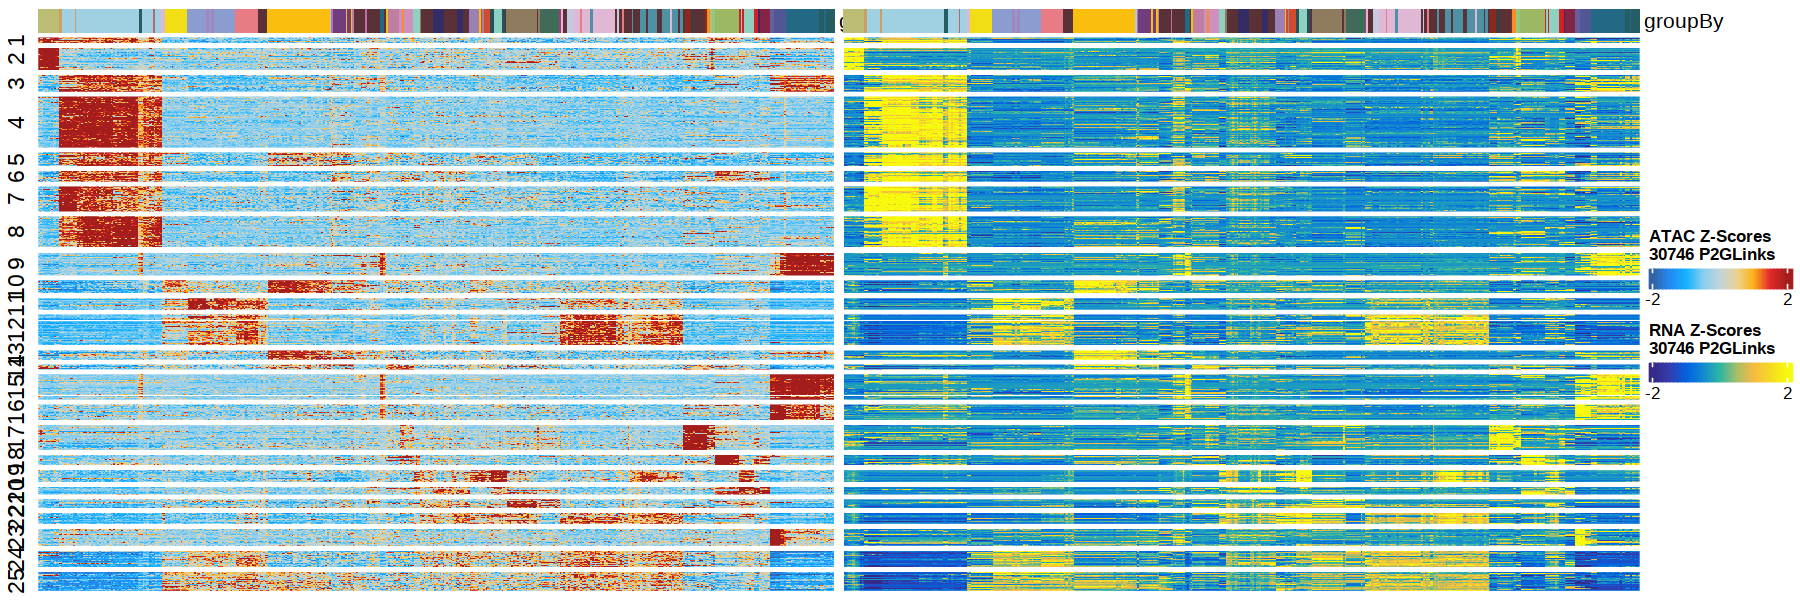

In [4]:
plotPeak2GeneHeatmap(ArchRProj = ArchRProject, groupBy = "celltype_v1")

# QC stats

In [ ]:
reads_in_peaks = colSums(peak_matrix@assays@data$PeakMatrix)

In [30]:
paste0('Median reads: ', median(ArchRProject@cellColData$nFrags))
paste0('Median reads in promoter: ', median(ArchRProject@cellColData$ReadsInPromoter))
paste0('Median proportion in promoter: ', round(median(ArchRProject@cellColData$PromoterRatio *100),1), '%')
paste0('Median reads in peaks: ', median(reads_in_peaks))


[1] "Median reads: 34347"

[1] "Median reads in promoter: 5955"

[1] "Median proportion in promoter: 8.6%"

[1] "Median reads in peaks: 20188"

In [12]:
peak_matrix = getMatrixFromProject(
  ArchRProj = ArchRProject,
    useMatrix = 'PeakMatrix')

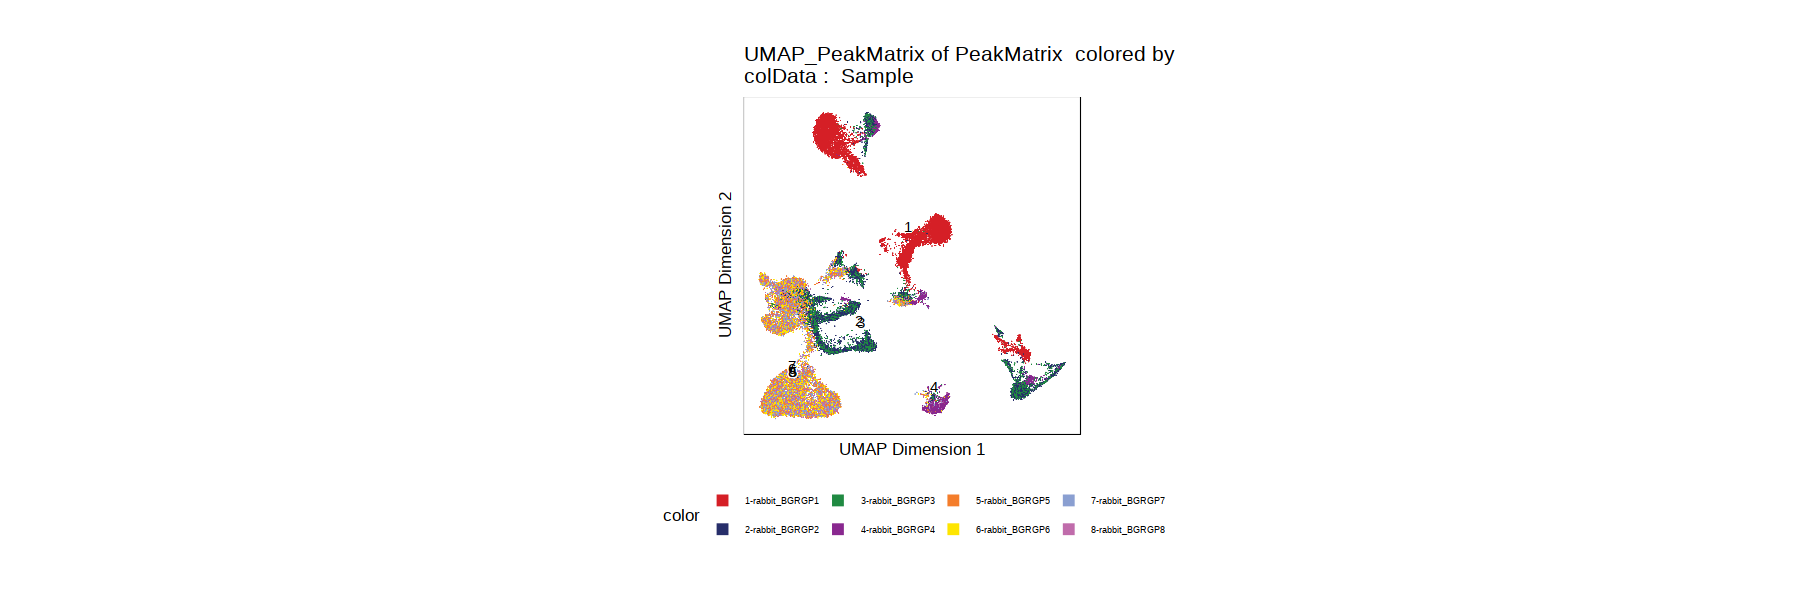

In [32]:
plotEmbedding(ArchRProject, 'UMAP_PeakMatrix')

# Plot genes

In [2]:
# List of possible genes to plot
genescore_genes = getFeatures(
  ArchRProj = ArchRProject,
  useMatrix = "GeneScoreMatrix")
genescore_genes = lapply(strsplit(genescore_genes, ":"), `[`, 2)

gene_integration_genes = getFeatures(
  ArchRProj = ArchRProject,
  useMatrix = "GeneIntegrationMatrix_PeakMatrix")
gene_integration_genes = lapply(strsplit(gene_integration_genes, ":"), `[`, 2)

all_genes = intersect(genescore_genes, gene_integration_genes)

In [39]:
 
all_genes[grep('ENSOCUG00000008523', all_genes)]

list()

In [42]:
all_genes[grep('FLT', all_genes)]

list()

In [3]:
plot_gene = function(gene){
    p1 = plotEmbedding(
        ArchRProj = ArchRProject, 
        colorBy = "GeneScoreMatrix", 
        name = gene, 
        embedding = "UMAP_PeakMatrix",
        imputeWeights = getImputeWeights(ArchRProject)
        ) + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle(gene, 'Gene Accessibility')

    p2 = plotEmbedding(
        ArchRProj = ArchRProject, 
        colorBy = "GeneIntegrationMatrix_PeakMatrix", 
        name = gene, 
        embedding = "UMAP_PeakMatrix",
        imputeWeights = getImputeWeights(ArchRProject)
        ) + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle('', 'Pseudo-Expression') 

    markerMotifs <- grep("z:", getFeatures(ArchRProject, select = gene, useMatrix = "MotifMatrix"), value = TRUE)
    if(length(markerMotifs>0)){
       p3 = plotEmbedding(
        ArchRProj = ArchRProject, 
        colorBy = "MotifMatrix", 
        name = markerMotifs[1], 
        embedding = "UMAP_PeakMatrix",
        imputeWeights = getImputeWeights(ArchRProject)
        ) + 
        scale_fill_viridis() + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle('', 'Motif Accessibility')
    }
        
 
    p4 = plotBrowserTrack(
        ArchRProj = ArchRProject, 
        groupBy = "celltype_manual", 
        geneSymbol = gene, 
        upstream = 20000,
        downstream = 20000,
        useMatrix = 'GeneIntegrationMatrix_PeakMatrix',
        #useMatrix = 'GeneScoreMatrix', # For Gata1 this didn't look good, don't know why
        loops = getPeak2GeneLinks(ArchRProject, resolution = 100)
    ) 

    if(length(markerMotifs>0)){
      umaps = ggarrange(p1, p2, p3, ncol = 3)
    }  else{umaps = ggarrange(p1, p2, ncol = 2)}
    track = ggarrange(p4[[1]])
   p = ggarrange(umaps, track, ncol=1, heights = c(5, 10))
   p
   
    outfile <- sprintf("%s/%s.pdf",io$plot.genes, gene)
    pdf(outfile, width=10, height=10)
        print(p)
    dev.off()
   
}

In [6]:
#     'ENSOCUG00000017835', # DNMT3B > epiblast
#     'ENSOCUG00000025597', # GATA1 -> blood
#     'ENSOCUG00000009246', # GCM1 --> SCT 
#     'ENSOCUG00000026343', # VTCN1 --> amniotic ectoderm
#     'ENSOCUG00000000041', # NKX2-5 > heart
#     'ENSOCUG00000010829', # MYL4 > cardiomyocytes
#     'ENSOCUG00000015170', # HOXA11 > Allantois
#     'ENSOCUG00000017248', # TAL1
#     'ENSOCUG00000000451', # EOMES
#     'ENSOCUG00000002633', # OTX2 > neural
#     'ENSOCUG00000004752', # SIX6 > neural
#     'ENSOCUG00000014268', # Six1 > neural
#     'ENSOCUG00000005360', # Noto > Notochord
#     'ENSOCUG00000007084', # CHR > notochord
#     'ENSOCUG00000011487', # DKK1 > Gut/AVE
#     'ENSOCUG00000010192' # CDH5 > endothelium

genes = c('GATA1','DNMT3B','GCM1','VTCN1',
         'MYL4','HOXA11','TAL1','EOMES','OTX2','SIX6', 
         'NOTO', 'CHR', 'DKK1', 'CDH5',
        'ELF5','CDK2', 'CDX4', 'ID1', 'ID2', 'SYN1', 'TEAD1', 'TFAP2B', 'VTCN1',
        'GATA2', 'GATA3', 'ETV', 'RUNX1', 'LAMB1', 'TFAP2C', 'APOA2', 
        'TTR', 'EMB',  'AMOT', 'KRT19', 'KRT8', 'KRT18','PAX6', 'PAX2', 'PECAM1', 'ANXA5', 
        'TFAP2A', 'PAX3', 'FOXD3', 'HESX1', 'LMO2', 'KDR', 'TNNT2', 'HOXA11', 'ACTA2', 'DLL1', 'ETV2',
        'MEOX1', 'TBX1', 'CDX2', 'MESP2', 'T', 'CER1', 'APELA', 'FOXA2', 'GSC', 'MIXL1', 'OTX2', 
        'DPPA3', 'NANOG', 'UTF1', 'EPCAM', 'POU5F1')


In [7]:
genes = genes[genes %in% all_genes]
genes

[1] "GATA1"  "DNMT3B" "GCM1"   "VTCN1"  "MYL4"   "HOXA11" "TAL1"   "EOMES" 
 [9] "OTX2"   "SIX6"   "NOTO"   "DKK1"   "CDH5"   "ELF5"   "CDX4"   "ID1"   
[17] "SYN1"   "TEAD1"  "TFAP2B" "VTCN1"  "GATA3"  "LAMB1"  "APOA2"  "EMB"   
[25] "AMOT"   "PAX6"   "PAX2"   "PECAM1" "ANXA5"  "TFAP2A" "PAX3"   "HESX1" 
[33] "LMO2"   "KDR"    "HOXA11" "ACTA2"  "MEOX1"  "CER1"   "FOXA2"  "MIXL1" 
[41] "OTX2"   "EPCAM"  "POU5F1"

In [8]:
run_plot_gene = function(gene){suppressMessages(plot_gene(gene))}
sapply(genes, run_plot_gene)

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]     chrX 33450832-33457631      + | ENSOCUG00000025597       GATA1
  -------
  seqinfo: 22 sequences from an unspecified genome


Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“Removed 29 rows containing missing values (position_stack).”


GRanges object with 1 range and 2 metadata columns:
      seqnames          ranges strand |            gene_id      symbol
         <Rle>       <IRanges>  <Rle> |        <character> <character>
  [1]     chr4 6631098-6649095      - | ENSOCUG00000017835      DNMT3B
  -------
  seqinfo: 22 sequences from an unspecified genome


Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“Removed 43 rows containing missing values (position_stack).”
Warning message:
“Removed 2 rows containing missing values (geom_segment).”


GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]    chr12 42896306-42912661      - | ENSOCUG00000009246        GCM1
  -------
  seqinfo: 22 sequences from an unspecified genome


...

GRanges object with 1 range and 2 metadata columns:
      seqnames              ranges strand |            gene_id      symbol
         <Rle>           <IRanges>  <Rle> |        <character> <character>
  [1]     chr2 138958143-138973213      - | ENSOCUG00000006223       EPCAM
  -------
  seqinfo: 22 sequences from an unspecified genome


Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“Removed 42 rows containing missing values (position_stack).”
Warning message:
“Removed 2 rows containing missing values (geom_segment).”


GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]    chr12 20168658-20173914      - | ENSOCUG00000017160      POU5F1
  -------
  seqinfo: 22 sequences from an unspecified genome


Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“Removed 15 rows containing missing values (position_stack).”


GATA1.png DNMT3B.png   GCM1.png  VTCN1.png   MYL4.png HOXA11.png   TAL1.png 
         2          2          2          2          2          2          2 
 EOMES.png   OTX2.png   SIX6.png   NOTO.png   DKK1.png   CDH5.png   ELF5.png 
         2          2          2          2          2          2          2 
  CDX4.png    ID1.png   SYN1.png  TEAD1.png TFAP2B.png  VTCN1.png  GATA3.png 
         2          2          2          2          2          2          2 
 LAMB1.png  APOA2.png    EMB.png   AMOT.png   PAX6.png   PAX2.png PECAM1.png 
         2          2          2          2          2          2          2 
 ANXA5.png TFAP2A.png   PAX3.png  HESX1.png   LMO2.png    KDR.png HOXA11.png 
         2          2          2          2          2          2          2 
 ACTA2.png  MEOX1.png   CER1.png  FOXA2.png  MIXL1.png   OTX2.png  EPCAM.png 
         2          2          2          2          2          2          2 
POU5F1.png 
         2

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]     chr1 88066143-88204956      - | ENSOCUG00000013415        FLI1
  -------
  seqinfo: 22 sequences from an unspecified genome


2022-01-24 18:15:23 : SuppressedMessaged due to getArchRVerbose() is FALSE!

Length of unique values greater than palette, interpolating..

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Length of unique values greater than palette, interpolating..

Warning message:
“Removed 6 rows containing missing values (position_stack).”
Picking joint bandwidth of 0.0143

Picking joint bandwidth of 0.000729

Picking joint bandwidth of 0.00863

Picking joint bandwidth of 0.0013

Picking joint bandwidth of 0.0179

Picking joint bandwidth of 0.0077

Picking joint bandwidth of 0.00454

Picking joint bandwidth of 0.137

Picking joint bandwidth of 0.0148

Picking joint bandwidth of 0.0345

Picking joint bandwidth of 0.114

Picking joi

$FLI1


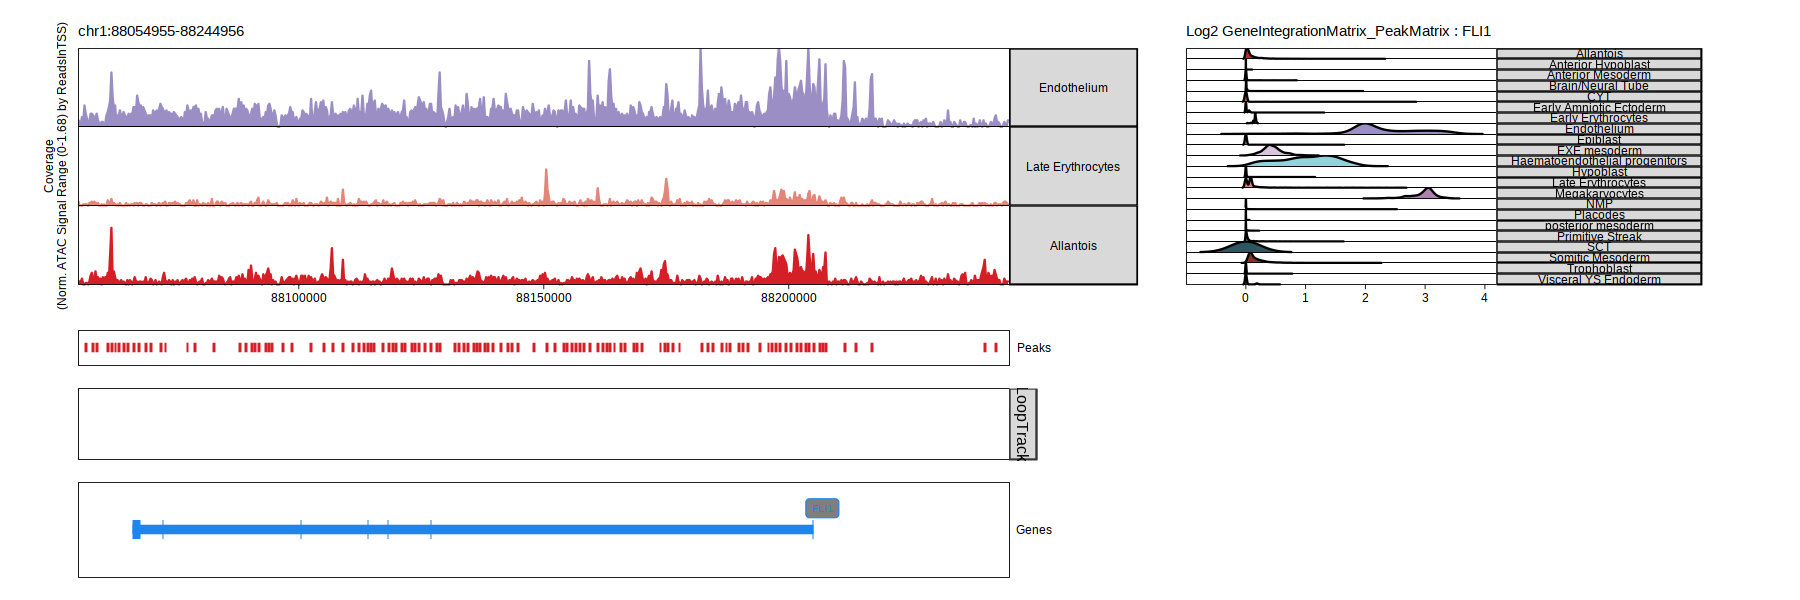

In [16]:
plotBrowserTrack(
        ArchRProj = ArchRProject, 
        groupBy = "celltype_manual", 
        useGroups = c('Endothelium', 'Late Erythrocytes', 'Allantois'),
        geneSymbol = 'FLI1', 
        upstream = 150000,
        downstream = 40000,
        useMatrix = 'GeneIntegrationMatrix_PeakMatrix',
        #useMatrix = 'GeneScoreMatrix', # For Gata1 this didn't look good, don't know why
        loops = getPeak2GeneLinks(ArchRProject, resolution = 1e8)
       # loops = getCoAccessibility(ArchRProject.filt, resolution = 10000)
    ) 

In [84]:
range = ArchRProject@geneAnnotation$genes[ArchRProject@geneAnnotation$genes$symbol == 'MAML3']

In [80]:
range = gr <- GRanges(
    seqnames = Rle(c("chr15"), 1),
    ranges = IRanges(24448616 + 3e5, end = 24922995),
    strand = Rle(strand(c("-")), 1))
range

GRanges object with 1 range and 0 metadata columns:
      seqnames            ranges strand
         <Rle>         <IRanges>  <Rle>
  [1]    chr15 24748616-24922995      -
  -------
  seqinfo: 1 sequence from an unspecified genome; no seqlengths

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]    chr15 24448616-24922995      + | ENSOCUG00000009376       MAML3
  -------
  seqinfo: 22 sequences from an unspecified genome


2022-01-24 18:07:45 : SuppressedMessaged due to getArchRVerbose() is FALSE!

Length of unique values greater than palette, interpolating..

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Length of unique values greater than palette, interpolating..

Warning message:
“Removed 5 rows containing missing values (position_stack).”
Picking joint bandwidth of 0.0175

Picking joint bandwidth of 0.0143

Picking joint bandwidth of 0.00487

Picking joint bandwidth of 0.0111

Picking joint bandwidth of 0.00794

Picking joint bandwidth of 0.00745

Picking joint bandwidth of 0.384

Picking joint bandwidth of 0.0248

Picking joint bandwidth of 0.0141

Picking joint bandwidth of 0.00748

Picking joint bandwidth of 0.00585

Picking j

$MAML3


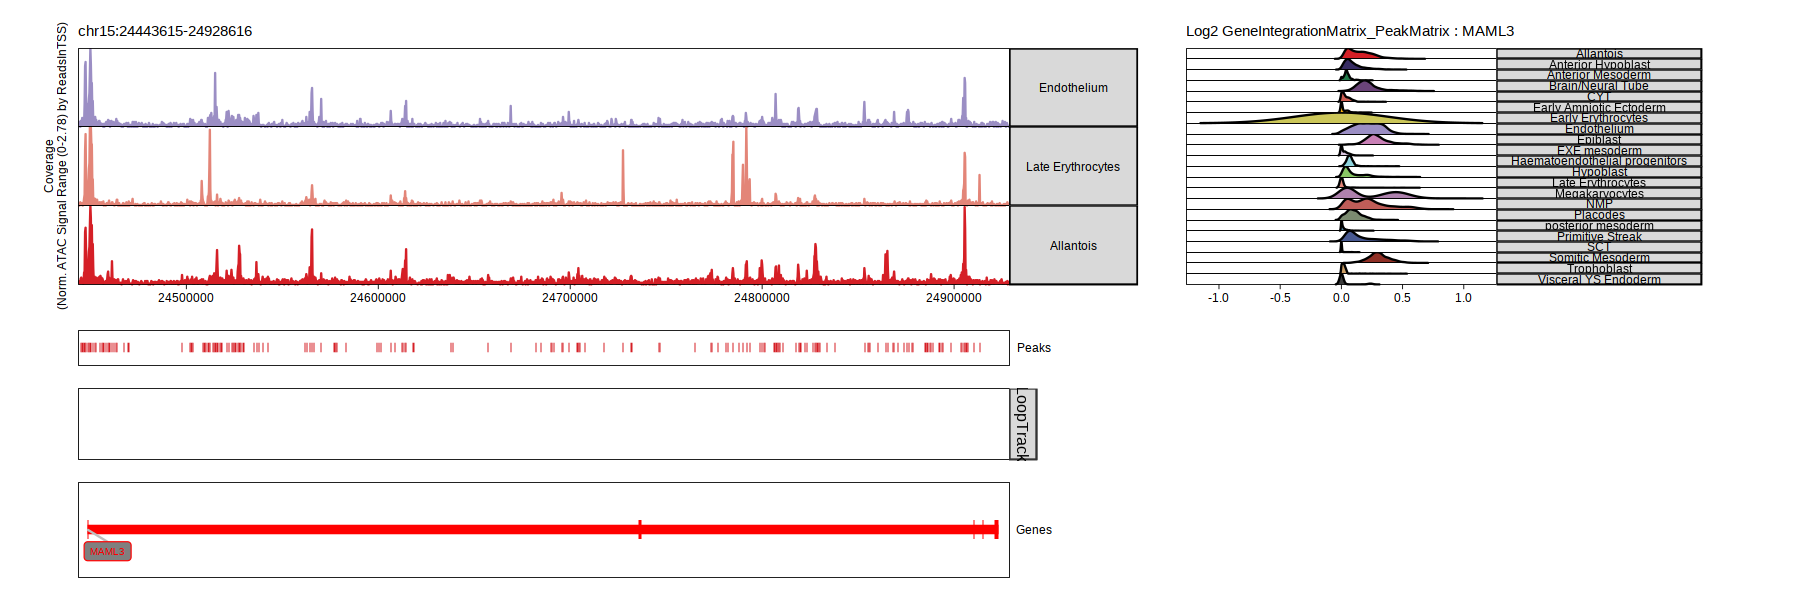

In [15]:
plotBrowserTrack(
        ArchRProj = ArchRProject, 
        groupBy = "celltype_manual", 
        useGroups = c('Endothelium', 'Late Erythrocytes', 'Allantois'),
        geneSymbol = 'MAML3', 
        upstream = 5000,
        downstream = 480000,
        useMatrix = 'GeneIntegrationMatrix_PeakMatrix',
        #useMatrix = 'GeneScoreMatrix', # For Gata1 this didn't look good, don't know why
        loops = getPeak2GeneLinks(ArchRProject, resolution = 1e8)
       # loops = getCoAccessibility(ArchRProject.filt, resolution = 10000)
    ) 